In [23]:
#import statements
import os
import datetime
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.patches import Circle, Ellipse
from matplotlib.collections import PatchCollection
from matplotlib.backends.backend_pdf import PdfPages
from mpl_toolkits.axes_grid1 import make_axes_locatable
from edge_pydb.conversion import kewley01, kauffm03, cidfer10
from astropy.visualization import PercentileInterval, ImageNormalize
from astropy.visualization import LinearStretch, SqrtStretch, LogStretch
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
from edge_pydb import EdgeTable
from edge_pydb.plotting import imarrayplot

In [24]:
#load tables
tglobal = EdgeTable('ecalifa_leda.csv', 
                    cols=['Name', 'ledaRA', 'ledaDE', 'ledaPA', 'ledaIncl', 'ledaD25', 'ledaAxIncl'])
tcalifa = EdgeTable('ecalifa_global.csv',
                    cols=['Name', 'Re'])
tglobal.join(tcalifa)
ssptab = EdgeTable('edge_carma_allpix.pipe3d.hdf5', 
                   path='SSP', 
                   cols=['Name', 'ix', 'iy', 'ra_abs', 'dec_abs', 'sigstar', 'fe_medflx'])

In [30]:
def gridplotv2(edgetab=None, gallist=None, columnlist=None,
               global_table=None, pixel_table=None, 
               xrange=None, yrange=None, blank=None, plotstyle='image',
               cmap='jet', nx=7, ny=6, dotsize=1, pdfname=None, pct=99,
               allnorm=False, vshow=True, clipedge=False, pad=5, verbose=False, 
               stretch='linear', maxlabel=18, do_cbar=True,
               show_center=False, show_ellipse=False,
               Re_col=None, PA_col=None, AxIncl_col=None,
               **kwargs):
    
    from matplotlib.patches import Ellipse
    from astropy.coordinates import SkyCoord
    import astropy.units as u
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.colors import LogNorm
    from matplotlib.colors import Normalize
    from astropy.visualization import ImageNormalize, PercentileInterval, LinearStretch, SqrtStretch, LogStretch
    from matplotlib.backends.backend_pdf import PdfPages

    Re_col = Re_col or 'Re'
    PA_col = PA_col or 'ledaPA'
    AxIncl_col = AxIncl_col or 'ledaAxIncl'

    def get_galaxy_center_pixel(galname, global_table=None, pixel_table=None):
        if global_table is None or pixel_table is None:
            return None
        galdata = global_table[global_table['Name'] == galname]
        if len(galdata) == 0: return None
        try:
            leda_ra = float(galdata['ledaRA'][0])
            leda_dec = float(galdata['ledaDE'][0])
            leda_coord = SkyCoord(ra=leda_ra*u.deg, dec=leda_dec*u.deg, frame='fk5')
        except Exception:
            return None
        galaxy_rows = pixel_table[pixel_table['Name'] == galname]
        if len(galaxy_rows) == 0: return None
        try:
            pixel_coords = SkyCoord(
                ra=np.array(galaxy_rows['ra_abs'])*u.deg,
                dec=np.array(galaxy_rows['dec_abs'])*u.deg,
                frame='fk5'
            )
            separations = leda_coord.separation(pixel_coords)
            nearest_idx = np.argmin(separations)
            ix = int(galaxy_rows['ix'][nearest_idx])
            iy = int(galaxy_rows['iy'][nearest_idx])
            pixel_ra = float(galaxy_rows['ra_abs'][nearest_idx])
            pixel_dec = float(galaxy_rows['dec_abs'][nearest_idx])
            offset_arcsec = separations[nearest_idx].to(u.arcsec).value
        except Exception:
            return None
        return ix, iy, pixel_ra, pixel_dec, offset_arcsec

    def add_ellipse(ax, galname, global_table, pixel_table):
        galdata = global_table[global_table['Name'] == galname]
        galaxy_rows = pixel_table[pixel_table['Name'] == galname]
        if len(galdata) == 0 or len(galaxy_rows) == 0:
            return
        center_info = get_galaxy_center_pixel(galname, global_table, pixel_table)
        if center_info is None:
            return

        ix_center, iy_center, _, _, _ = center_info

        pix_scale = np.abs(galaxy_rows['dec_abs'][1] - galaxy_rows['dec_abs'][0]) * 3600

        Re_arcsec = float(galdata[Re_col][0])
        ax_incl_deg = float(galdata[AxIncl_col][0])
        pa_deg = float(galdata[PA_col][0])

        a_pix = Re_arcsec / pix_scale
        b_pix = a_pix * np.cos(np.radians(ax_incl_deg))
        theta_deg = pa_deg + 90

        if verbose:
            print(f"\n=== Ellipse debug for {galname} ===")
            print("ix_center_panel:", ix_center)
            print("iy_center_panel:", iy_center)
            print("a_pix:", a_pix)
            print("b_pix:", b_pix)
            print("theta:", theta_deg)

        ell = Ellipse(
            (ix_center, iy_center),
            width=2*a_pix,
            height=2*b_pix,
            angle=theta_deg,
            edgecolor='red',
            facecolor='none',
            lw=2
        )
        ax.add_patch(ell)
        ax.plot(ix_center, iy_center, marker='o', color='red',
                markersize=14, markeredgewidth=3, markeredgecolor='black')

    match stretch:
        case 'linear': stretch = LinearStretch()
        case 'sqrt': stretch = SqrtStretch()
        case 'log': stretch = LogStretch()
        case _: stretch = LinearStretch()

    if gallist is None and columnlist is None:
        raise TypeError('Either gallist or columnlist must be provided!')
    if isinstance(gallist, str): gallist = [gallist]
    if isinstance(columnlist, str): columnlist = [columnlist]
    if 'norm' in kwargs: kwargs.pop('norm')

    if columnlist is not None and len(columnlist) == 1:
        mode = 'onecol'
        if gallist is None:
            gallist = list(np.unique(edgetab['Name']))
        pagelist = gallist
        if allnorm:
            vmin, vmax = PercentileInterval(pct).get_limits(edgetab[columnlist[0]])
            norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    elif gallist is not None and len(gallist) == 1:
        mode = 'onegal'
        if columnlist is None:
            columnlist = [c for c in edgetab.colnames if c not in 
                          ['Name','ix','iy','ra_abs','dec_abs','ra_off','dec_off']]
        pagelist = columnlist
        if allnorm:
            vmin, vmax = PercentileInterval(pct).get_limits(
                edgetab[edgetab['Name']==gallist[0]][columnlist])
            norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    else:
        raise ValueError('Specify either one galaxy or one column to plot')

    pages = int(np.ceil(len(pagelist)/(nx*ny)))
    if pdfname: pp = PdfPages(pdfname)

    for num in range(pages):
        aa, bb = nx*ny*num, nx*ny*(num+1)
        thispage = pagelist[aa:bb]
        fig = plt.figure(figsize=(18,14))
        cbar_done = False

        for i, item in enumerate(thispage):
            ax = plt.subplot(ny,nx,i+1)
            if mode == 'onecol':
                gname = item
                column = columnlist[0]
            else:
                gname = gallist[0]
                column = item
            galtab = (edgetab['Name'] == gname)
            galblank = blank[galtab] if blank is not None else None

            if not np.isnan(edgetab[galtab][column]).all():
                if not allnorm:
                    vmin, vmax = PercentileInterval(pct).get_limits(edgetab[galtab][column])
                    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)

                if plotstyle == 'dot':
                    img, xlims, ylims = dotpatch(edgetab[galtab]['ix'],
                                                 edgetab[galtab]['iy'],
                                                 edgetab[galtab][column],
                                                 blank=galblank, clipedge=clipedge,
                                                 pad=pad, dotsize=dotsize, cmap=cmap,
                                                 norm=norm, axes=ax, **kwargs)
                else:
                    img, xlims, ylims = imarrayplot(edgetab[galtab]['ix'],
                                                   edgetab[galtab]['iy'],
                                                   edgetab[galtab][column],
                                                   blank=galblank, clipedge=clipedge,
                                                   pad=pad, cmap=cmap,
                                                   norm=norm, axes=ax, **kwargs)

                ax.set_xlim(xrange if xrange else xlims)
                ax.set_ylim(yrange if yrange else ylims)

                if show_center:
                    center_info = get_galaxy_center_pixel(gname, global_table, pixel_table)
                    if center_info:
                        ix, iy, _, _, _ = center_info
                        ax.plot(ix, iy, marker='x', color='red', markersize=20, markeredgewidth=2.5)

                if show_ellipse:
                    add_ellipse(ax, gname, global_table, pixel_table)

                if vshow:
                    labelstr = '[{:.3f} .. {:.3f}]'.format(vmin,vmax) if vmax < 1 else '[{:.2f} .. {:.2f}]'.format(vmin,vmax)
                    if hasattr(edgetab[galtab][column], 'unit') and edgetab[galtab][column].unit is not None:
                        if len(edgetab[galtab][column].unit.to_string()) <= maxlabel:
                            labelstr += f" {edgetab[galtab][column].unit:latex_inline}"
                    plt.text(0.04,0.06,labelstr,ha='left',va='center',size='small',transform=ax.transAxes,
                             bbox=dict(boxstyle='square,pad=0.1',facecolor='white',edgecolor='none'))

                if do_cbar and not cbar_done:
                    cax = ax.inset_axes([0.0, -0.07, 1.0, 0.04])
                    cbar = fig.colorbar(img, cax=cax, orientation='horizontal')
                    if allnorm:
                        cbar.ax.tick_params(labelsize='x-small')
                        cbar.ax.tick_params(size=0)
                    else:
                        cbar.set_ticks([])
                    cbar_done = True

            ax.set_aspect('equal')
            ax.xaxis.set_ticks([])
            ax.yaxis.set_ticks([])
            plt.text(0.04,0.92, column if mode=='onegal' else gname, ha='left', va='center',
                     transform=ax.transAxes, bbox=dict(facecolor='white', edgecolor='none', pad=1))

        fig.subplots_adjust(hspace=0.1, wspace=0.05)
        if pdfname:
            pp.savefig(bbox_inches='tight', pad_inches=0.1)
            plt.close()
        else:
            plt.show()
    if pdfname: pp.close()


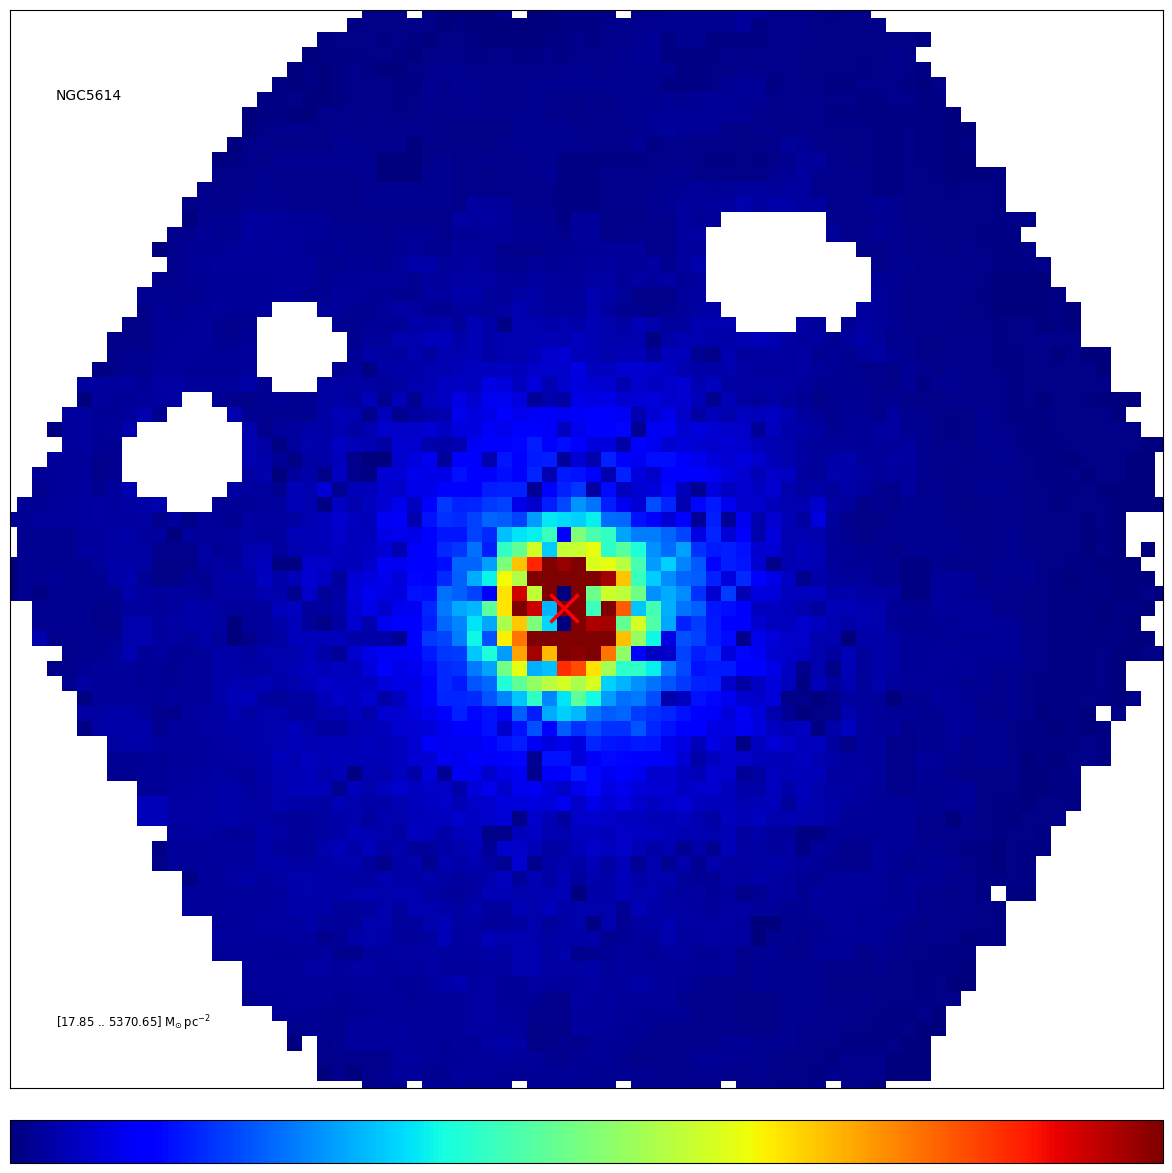

In [31]:
#test 1:
#testing 1 galaxy, onecol mode
gridplotv2(
    edgetab=ssptab,
    gallist=['NGC5614'],
    columnlist=['sigstar'],
    nx=1, ny=1,
    global_table=tglobal,
    pixel_table=ssptab,
    show_center=True
)

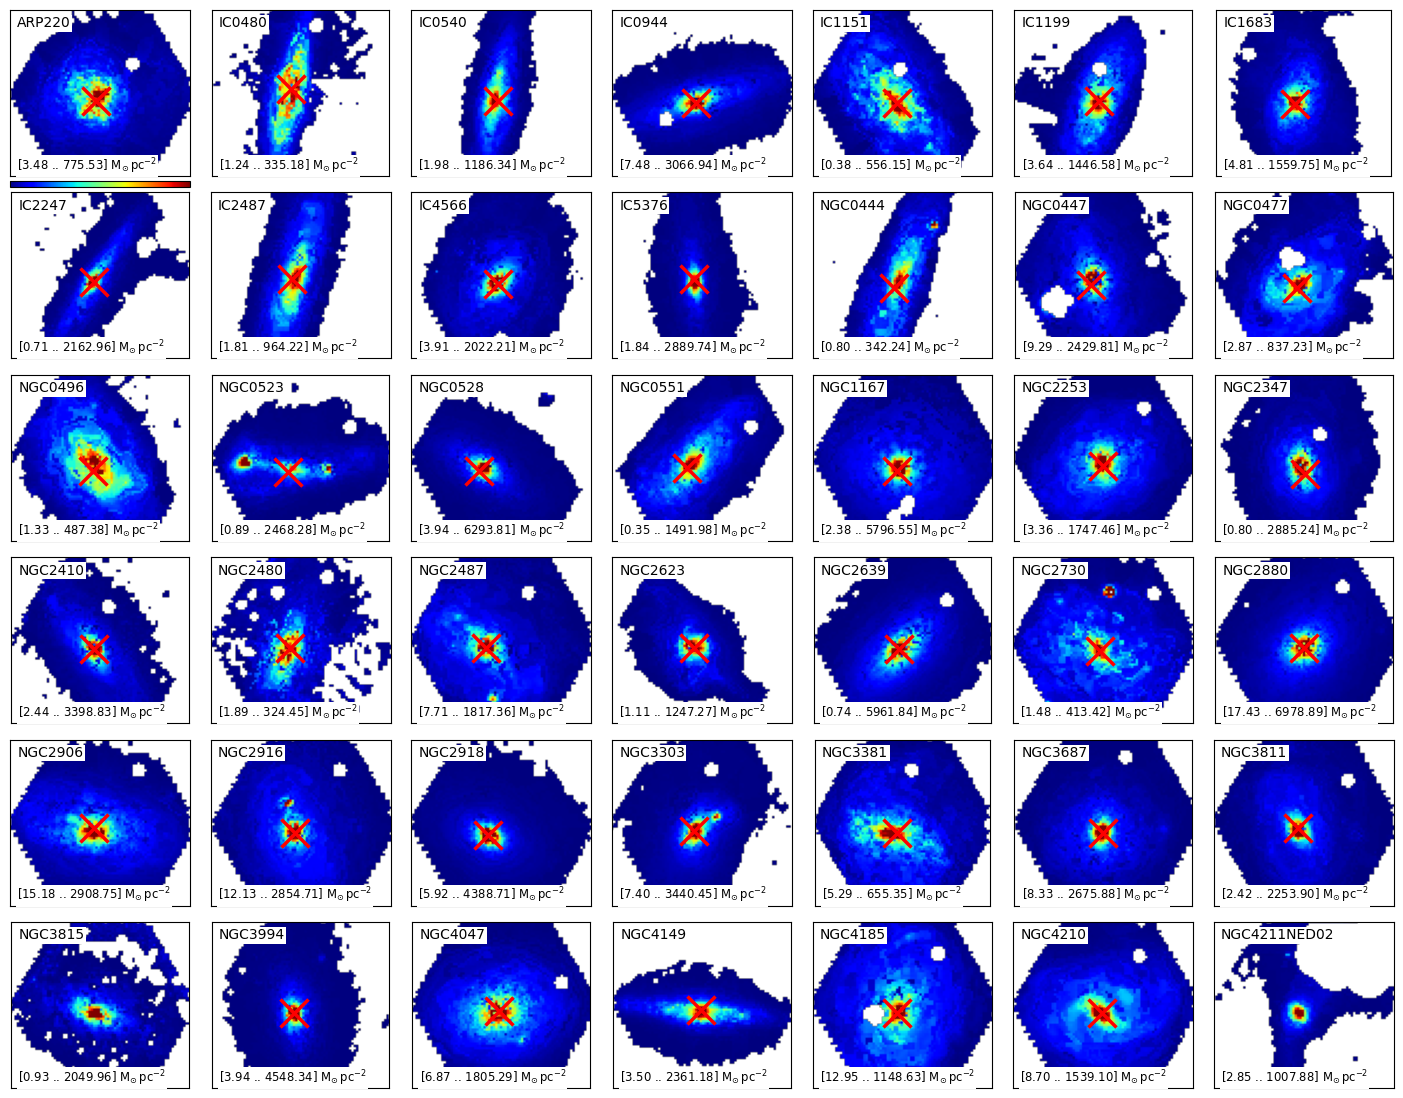

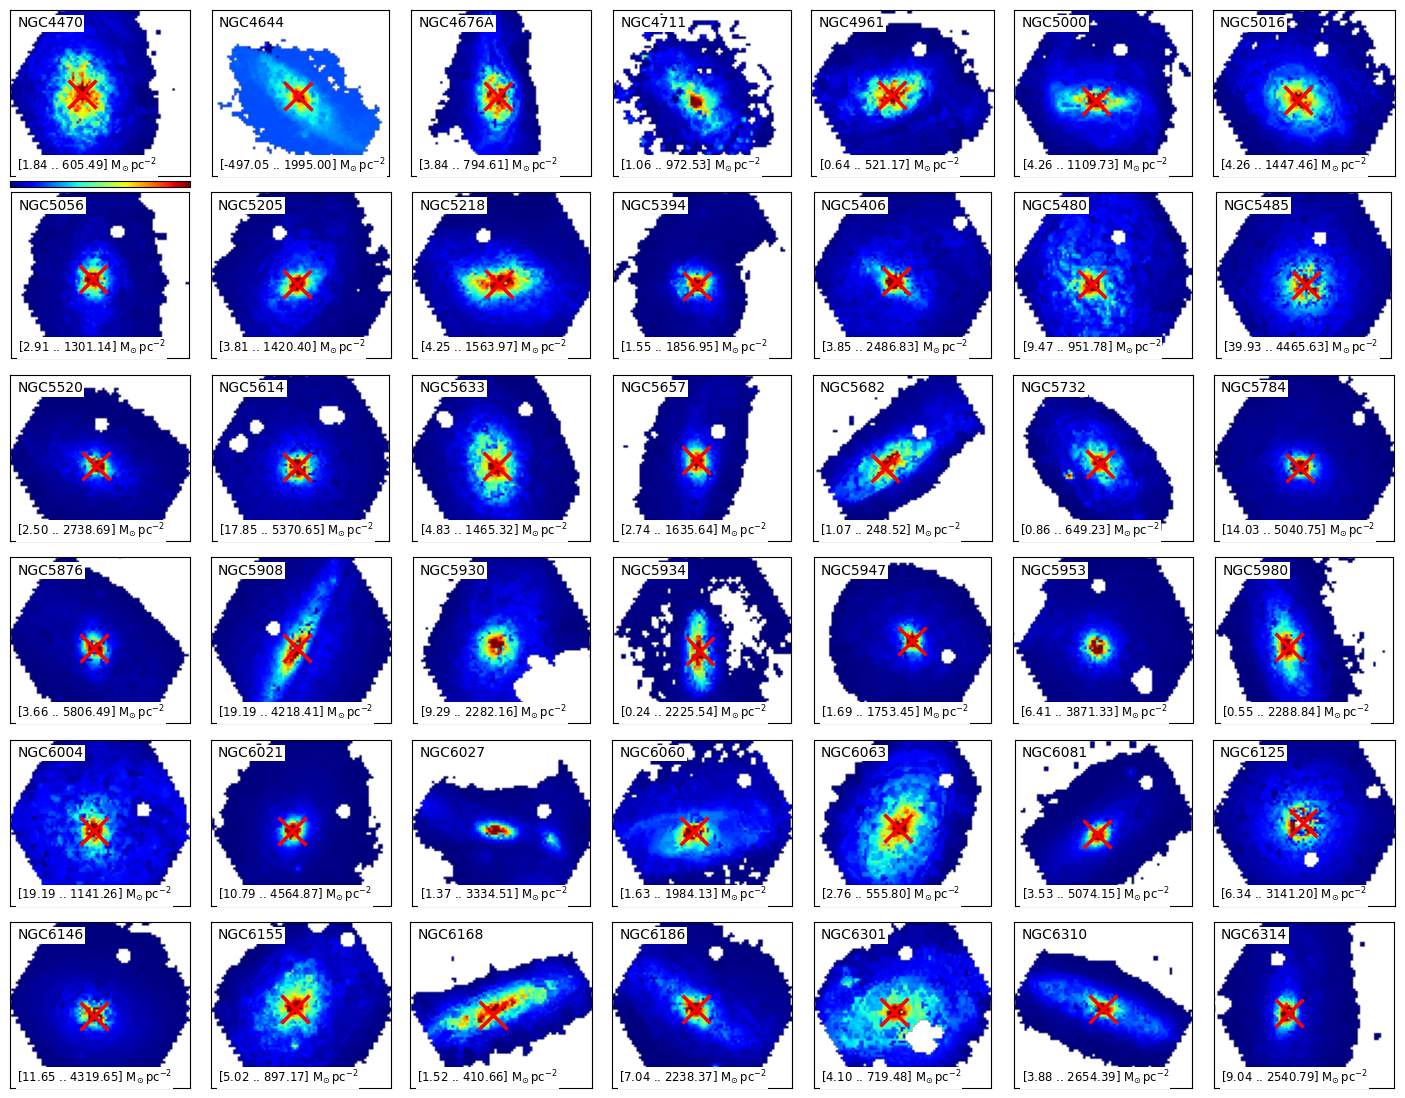

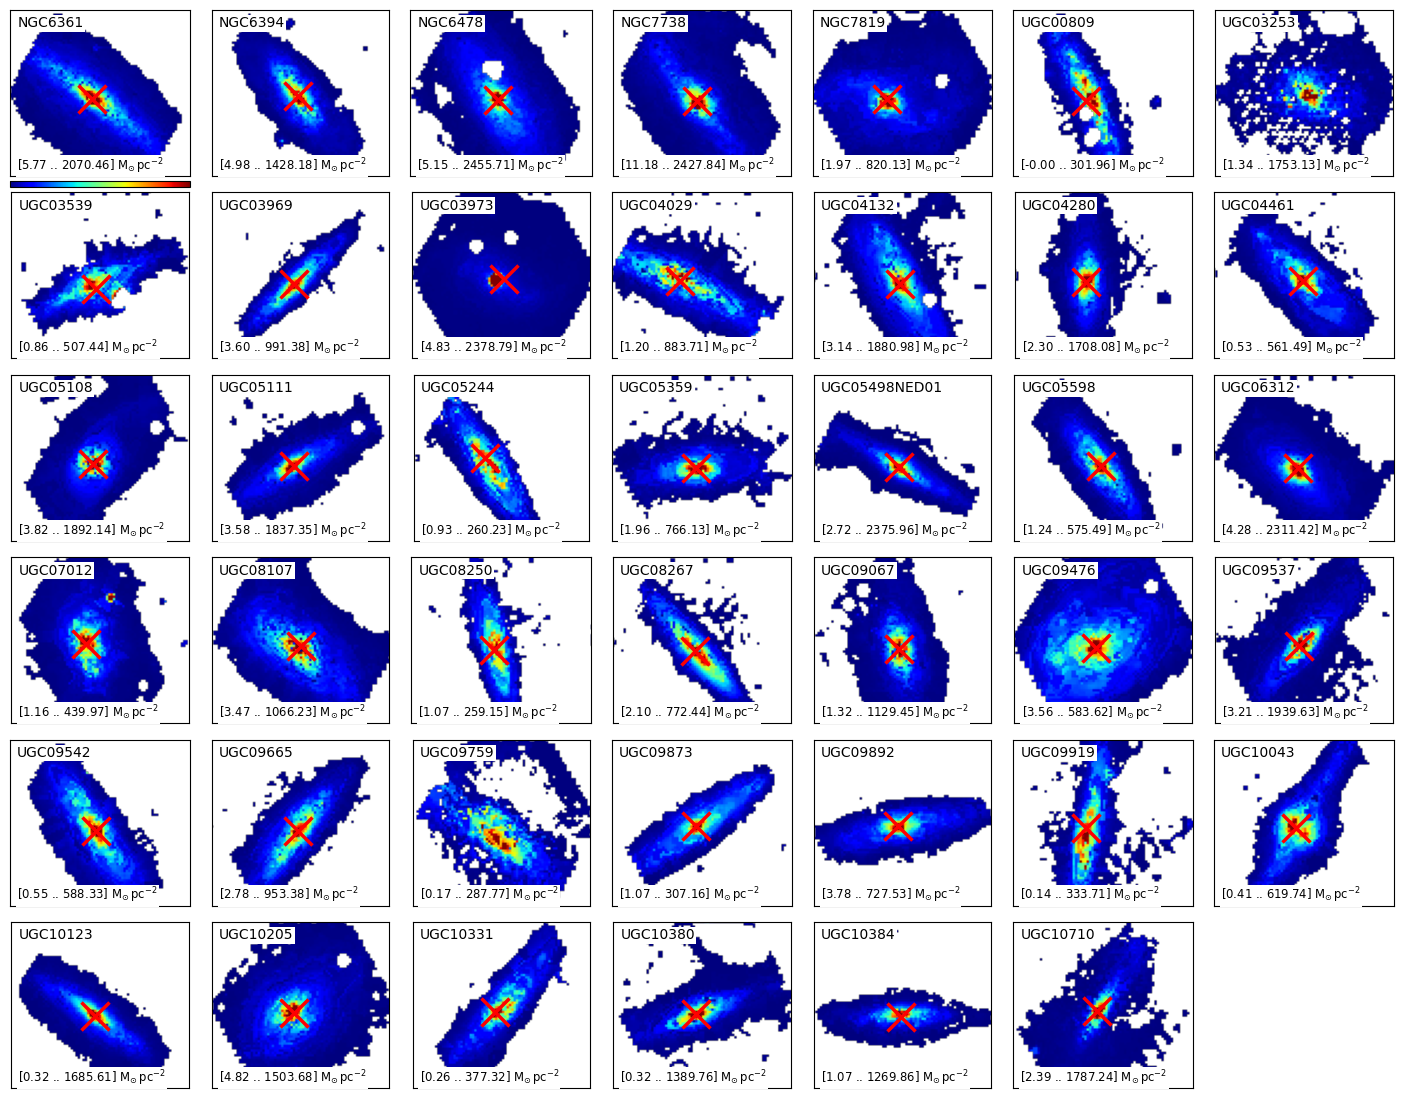

In [5]:
#test 2:
#testing multipanel ability, using all of galaxies in ssptab
gridplotv2(
    edgetab=ssptab,
    gallist=np.unique(ssptab['Name']),
    columnlist=['sigstar'],
    nx=7,
    ny=6,
    global_table=tglobal,
    pixel_table=ssptab,
    show_center=True,
    cmap='jet'
)

In [6]:
#test 3: 
#testing PDF saving
gridplotv2(
    edgetab=ssptab,
    gallist=np.unique(ssptab['Name']),
    columnlist=['sigstar'],
    nx=7,
    ny=6,
    global_table=tglobal,
    pixel_table=ssptab,
    show_center=True,
    cmap='jet',
    pdfname='test_output.pdf'
)

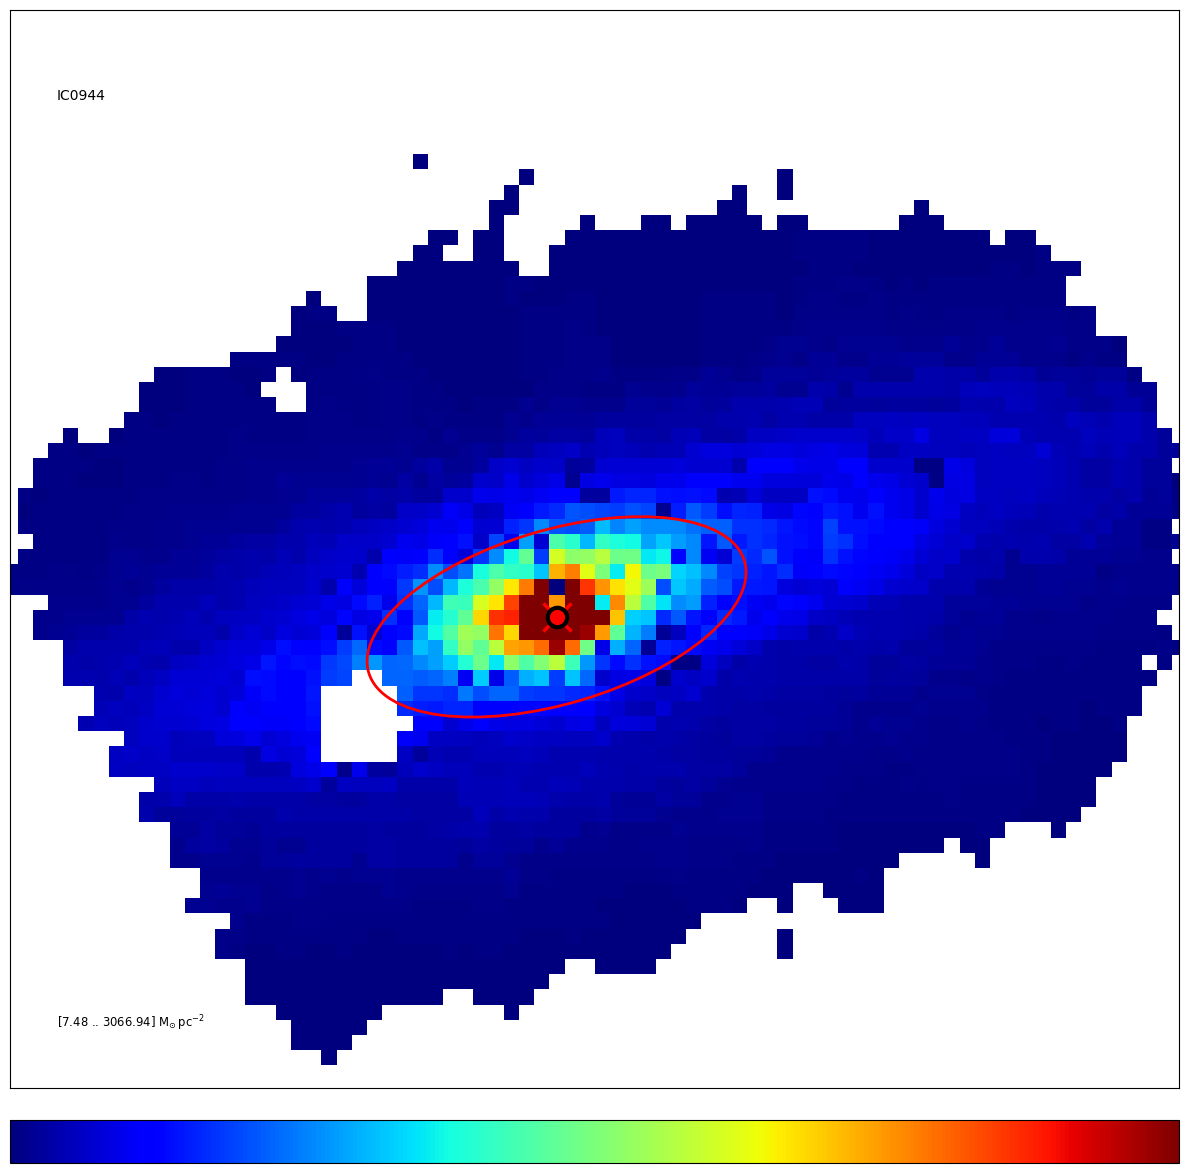

In [7]:
#test 4:
#testing one galaxy, onecol mode, center AND ellipse
gridplotv2(
    edgetab=ssptab,
    gallist=['IC0944'],
    columnlist=['sigstar'],
    global_table=tglobal,
    pixel_table=ssptab,
    nx=1, ny=1,
    plotstyle='image',
    cmap='jet',
    show_center=True,
    show_ellipse=True
)

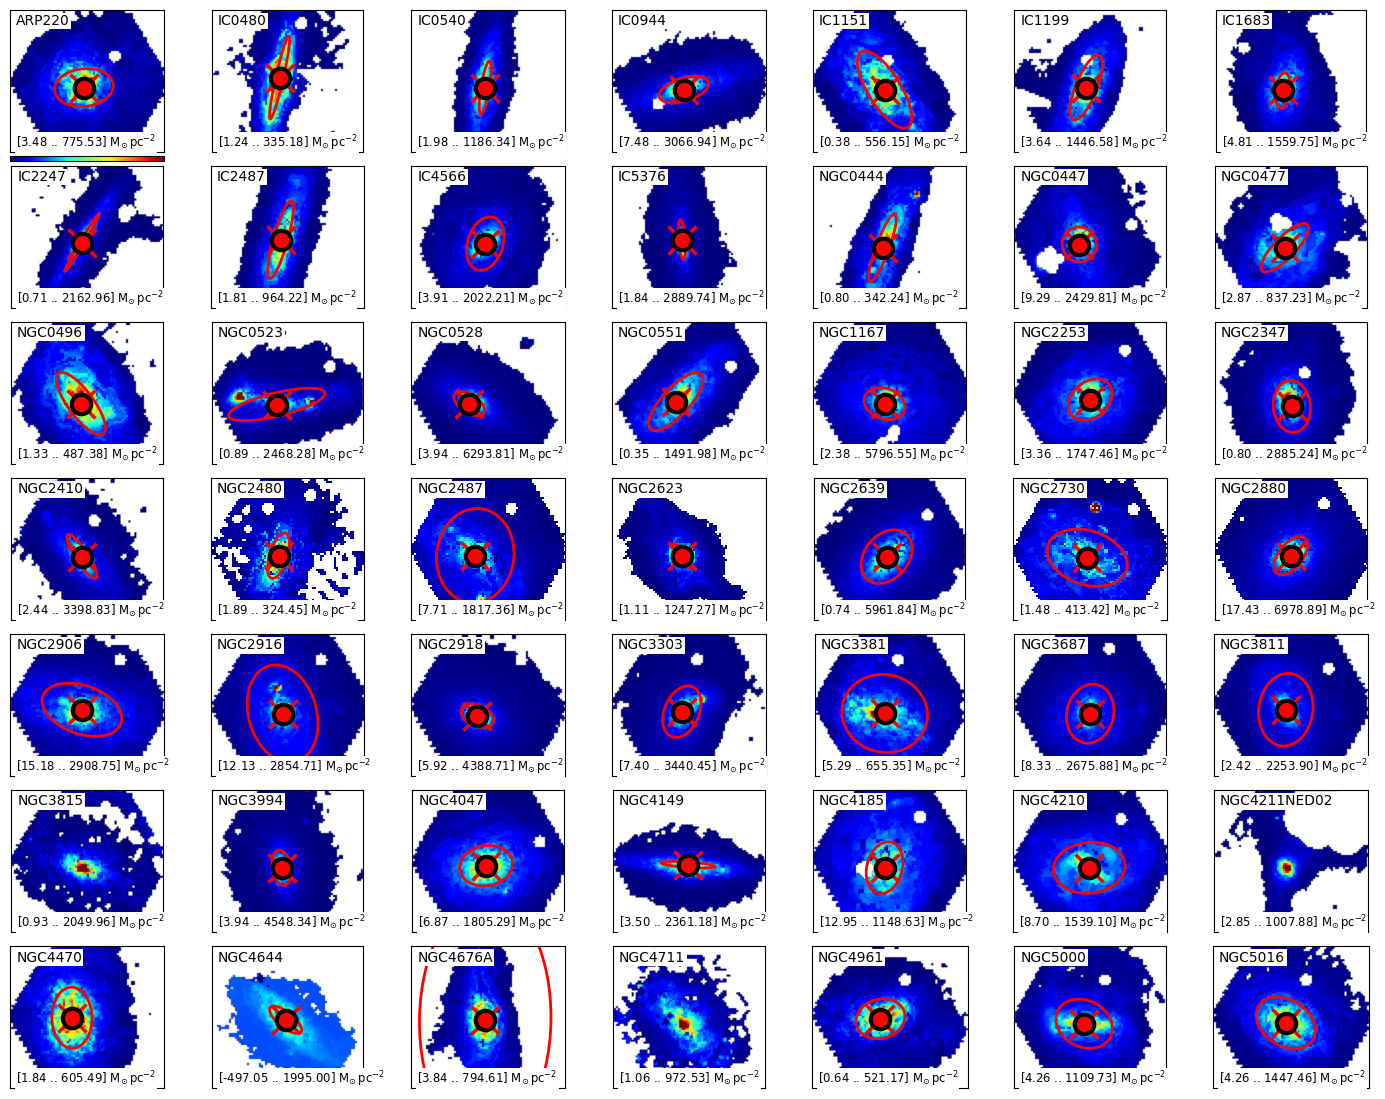

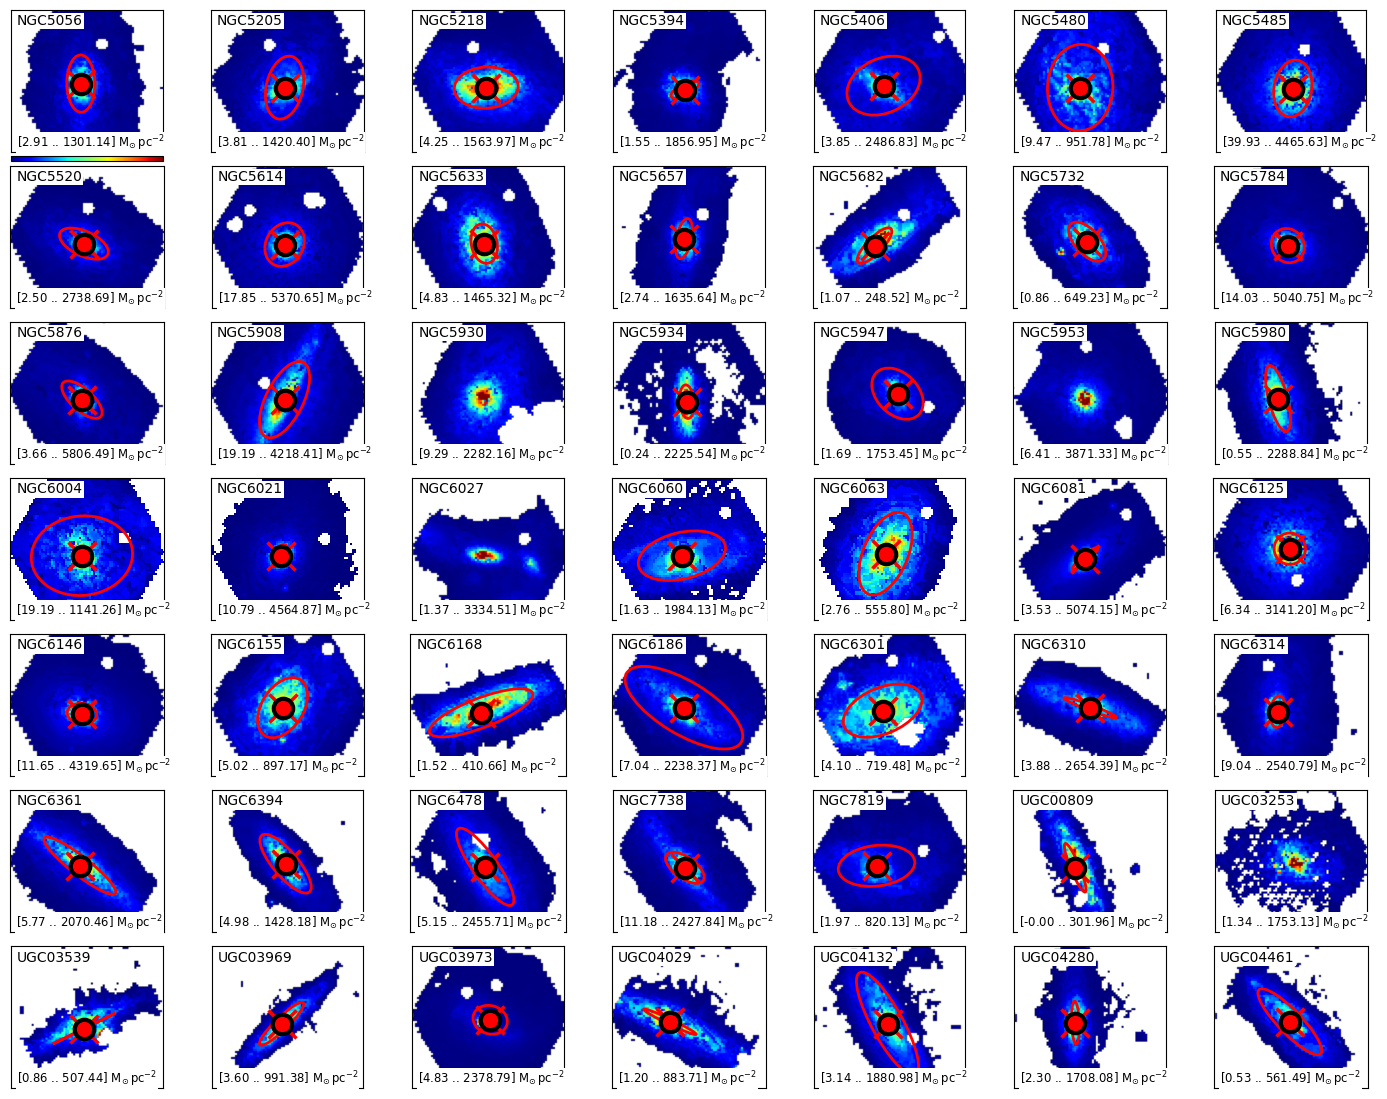

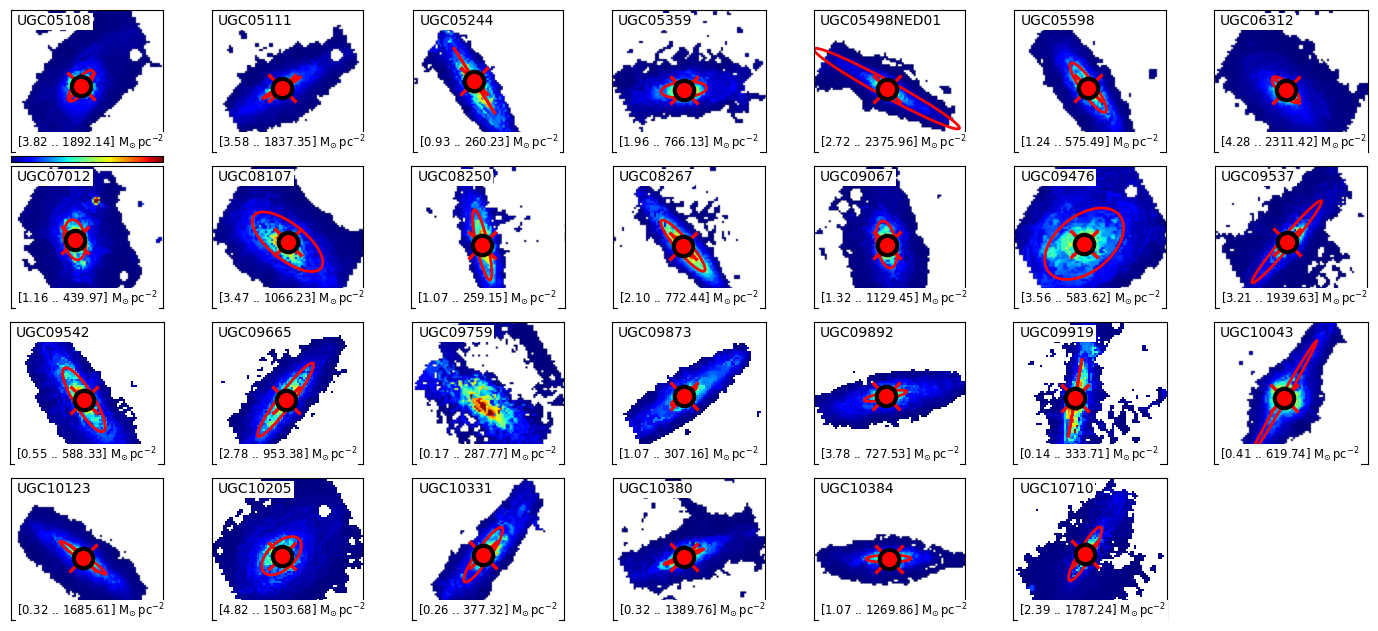

In [8]:
#test 5:
#try plotting all the galaxies with ellipse
gridplotv2(
    edgetab=ssptab,
    gallist=np.unique(ssptab['Name']),
    columnlist=['sigstar'],
    global_table=tglobal,
    pixel_table=ssptab,
    nx=7, ny=7,
    plotstyle='image',
    cmap='jet',
    show_center=True,
    show_ellipse=True
)

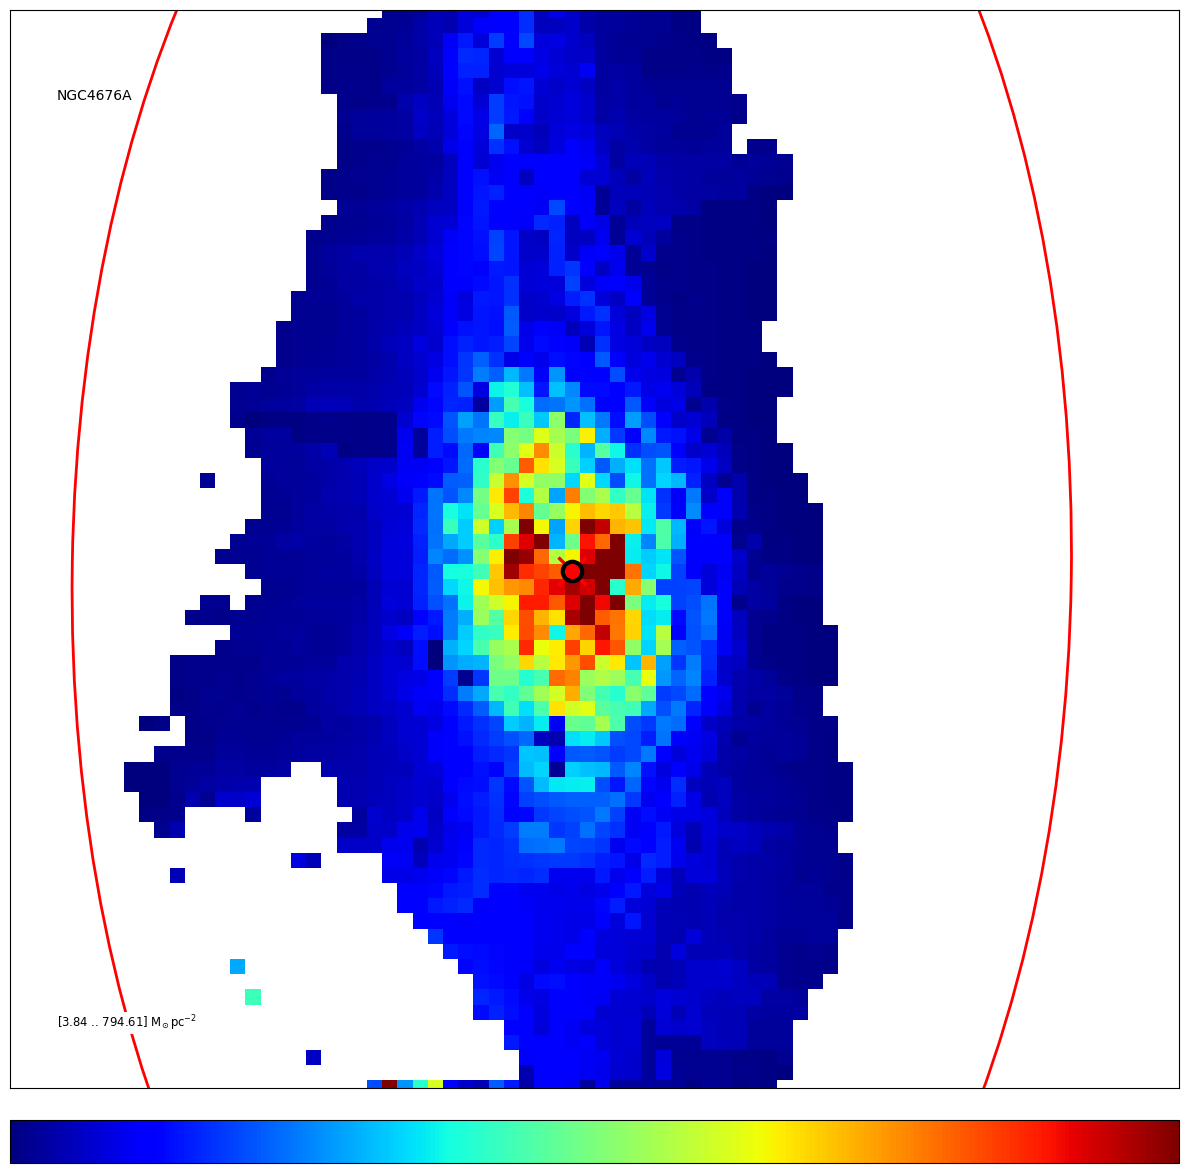

In [9]:
#test 6:
#checking ix and iy center values
gridplotv2(
    edgetab=ssptab,
    gallist=['NGC4676A'],
    columnlist=['sigstar'],
    global_table=tglobal,
    pixel_table=ssptab,
    nx=1, ny=1,
    plotstyle='image',
    cmap='jet',
    show_center=True,
    show_ellipse=True
)

In [18]:
from edge_pydb import EdgeTable

alma_tab = EdgeTable("almaquest_allpix.2d_preregrid.hdf5", path="ELINES")
manga_tab = EdgeTable("manga_global.csv")

print(alma_tab.colnames)

['Name', 'ix', 'iy', 'ra_abs', 'dec_abs', 'ra_off', 'dec_off', 'rad_arc', 'azi_ang', 'Havel', 'Vdisp', '[OII]3727', '[OIII]5007', '[OIII]4959', 'Hbeta', 'Halpha', '[NII]6583', '[NII]6548', '[SII]6731', '[SII]6717', 'Hbeta_sm2', 'Halpha_sm2', 'sigsfr0', 'sigsfr_corr', 'AHa_corr', 'AHa_corr_sm2', 'sigsfr_corr_sm2']


In [21]:

alma_names = set(alma_tab['Name'])
manga_names = set(manga_tab['Name'])

common = sorted(alma_names & manga_names)
print(common[:20])

['7815-12705', '7964-1902', '7968-12705', '7975-6104', '7977-12705', '7977-3703', '7977-3704', '7977-9101', '7977-9102', '8077-6104', '8077-9101', '8078-12701', '8078-12703', '8078-6103', '8078-6104', '8080-3704', '8081-12703', '8081-3702', '8081-3704', '8081-6102']


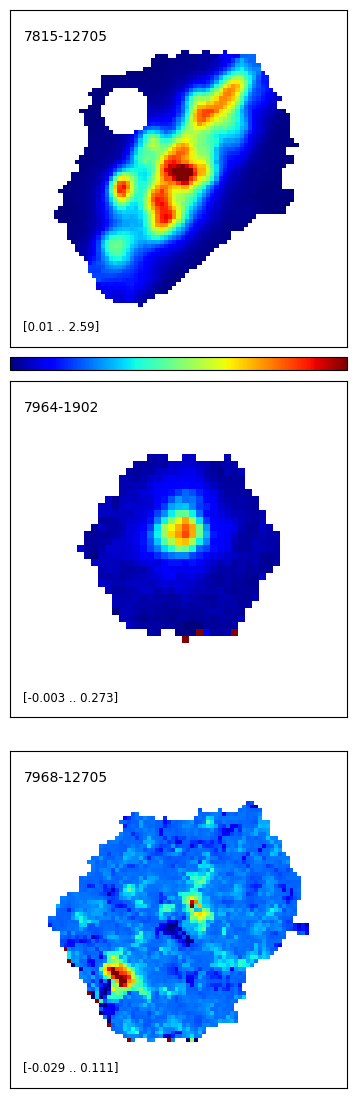

In [34]:
gridplotv2(
    edgetab=alma_tab,
    gallist=common[:3],
    columnlist=['Halpha'],
    global_table=manga_tab,
    pixel_table=alma_tab,
    nx=1, ny=3,
    plotstyle='image',
    cmap='jet',
    show_center=True,
    show_ellipse=True,
    Re_col='Re_arc',
    PA_col='PA',
    AxIncl_col='ellip',
    clipedge = True,
    pad = 10
)